# 04 · Clustering in real time

A batch estimator sees every window before deciding anything. A stream does
not wait. `lrdsr.core.online` has two real-time estimators:

* **`OnlineLRDSR`** — window by window. Each regime keeps the sufficient
  statistics of its law (recursive least squares), so a window is scored,
  assigned and absorbed in microseconds. A window **no** law explains is
  buffered, and a buffer of mutually consistent ones becomes a **new regime**.
  A forgetting factor lets laws drift.
* **`CusumSegmenter`** — sample by sample. With the laws known or learned, a
  single stream that switches regime at unknown times is segmented by CUSUM
  on the log-likelihood ratio, with a delay the theory predicts:
  $\approx h / \mathrm{KL} = 2h/\rho$ samples.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

## 1 · A stream in which a new law appears

Two laws for the first 100 windows; from then on a third one, never seen in
the history, arrives too. The model is warm-started on 40 windows of history
**without labels** (a 2-regime `SoftLRDSR` fit), then run.

In [2]:
from lrdsr import OnlineLRDSR
from lrdsr.core.evaluation import aligned_accuracy

rng = np.random.default_rng(11)
laws = [lambda x: x**2 + x, lambda x: x**2 - x, lambda x: 2 * np.sin(3 * x)]
n, sigma = 32, 1.0

def windows(ks):
    x = rng.uniform(-2, 2, (len(ks), n))
    y = np.stack([laws[k](x[i]) for i, k in enumerate(ks)]) + rng.normal(0, sigma, x.shape)
    return x[:, :, None], y

z_hist = rng.integers(0, 2, 40)
X_hist, y_hist = windows(z_hist)
z = np.r_[rng.integers(0, 2, 100), rng.choice(3, 140)]
X, y = windows(z)

online = OnlineLRDSR(feature_names=["x"], novelty_alpha=1e-3, novelty_patience=6)
online.warm_start(X_hist, y_hist, n_clusters=2)
timeline = online.fit_stream(X, y, true_labels_for_eval=z)
born = timeline.loc[timeline.spawned.notna(), "t"].tolist()
first = int(np.argmax(z == 2))
ok = timeline.label >= 0
print(f"regimes at the end: {online.n_clusters}; third law first seen at window {first}, "
      f"born at {born}")
print(f"accuracy on assigned windows: {aligned_accuracy(z[ok], timeline.label[ok]):.3f}; "
      f"windows held in the novelty buffer: {(~ok).sum()}")

regimes at the end: 3; third law first seen at window 101, born at [129]
accuracy on assigned windows: 1.000; windows held in the novelty buffer: 5


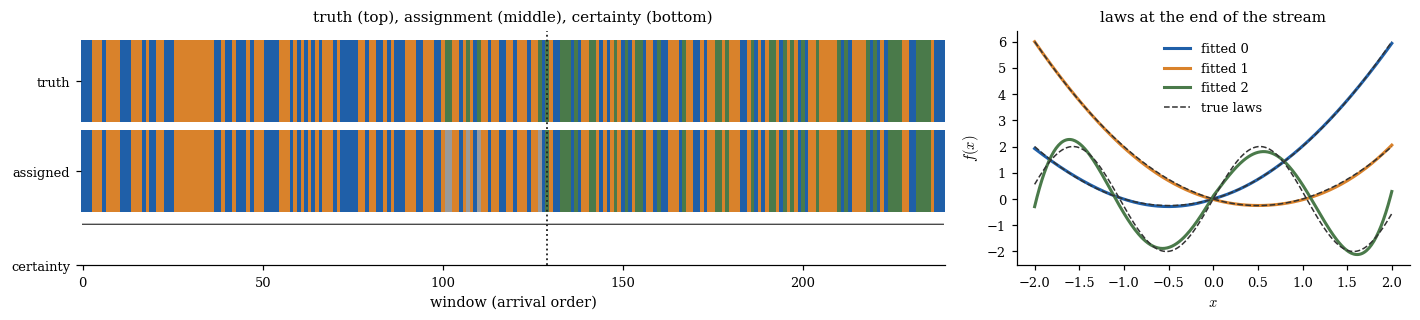

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.0), gridspec_kw={"width_ratios": [2.2, 1]})
viz.plot_stream(timeline, ax=ax[0], title="truth (top), assignment (middle), certainty (bottom)")
viz.plot_laws(coef=online.coef_, feature_names=["x"], truth=laws, ax=ax[1])
ax[1].set_title("laws at the end of the stream")
fig.tight_layout()

## 2 · Watch it run

The animation below **is** the run: each frame feeds the next windows to a
fresh model, the laws are redrawn from its current statistics, and the
timeline grows. The third law appears when its regime is born.

In [4]:
from IPython.display import HTML
import matplotlib as mpl
mpl.rcParams["animation.embed_limit"] = 40

live = OnlineLRDSR(feature_names=["x"], novelty_alpha=1e-3, novelty_patience=6)
live.warm_start(X_hist, y_hist, n_clusters=2)
anim = viz.animate_stream(live, X, y, truth=z, every=8, interval=200, x_range=(-2, 2), dpi=60)
HTML(anim.to_jshtml())

## 3 · How fast is "real time"?

In [5]:
import time
bench = OnlineLRDSR(feature_names=["x"]).warm_start(X_hist, y_hist, n_clusters=2)
t0 = time.perf_counter()
for w in range(len(y)):
    bench.partial_fit(X[w], y[w])
dt = (time.perf_counter() - t0) / len(y)
print(f"{dt * 1e6:.0f} µs per window of {n} samples  ->  {1 / dt:,.0f} windows / s")

274 µs per window of 32 samples  ->  3,645 windows / s


## 4 · Laws that drift: forgetting

One law's slope drifts from $+1$ to $-0.5$ over the stream. With
$\lambda = 1$ the regime's statistics average the whole past; with
$\lambda < 1$ they remember $\sim 1/(1-\lambda)$ windows and track it.

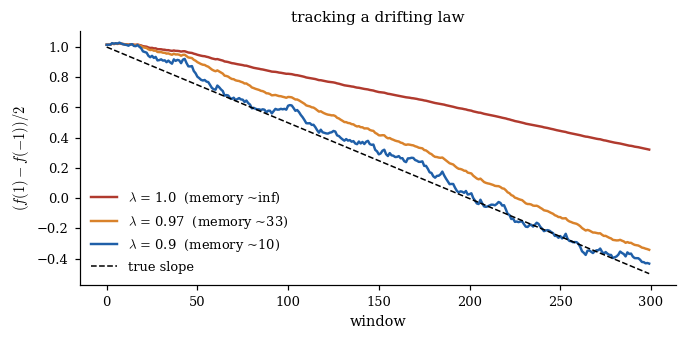

In [6]:
T = 300
slope = np.linspace(1.0, -0.5, T)
xs = rng.uniform(-2, 2, (T, n))
ys = xs**2 + slope[:, None] * xs + rng.normal(0, 0.5, xs.shape)
Xh = rng.uniform(-2, 2, (30, n)); yh = Xh**2 + Xh + rng.normal(0, 0.5, Xh.shape)
# The library is collinear (x, x^3, sin x, ...), so no single coefficient is
# identifiable; the LAW is. Track its odd part at x = 1, (f(1) - f(-1)) / 2,
# which for x^2 + s x is exactly the slope s.
from lrdsr.core.soft import library_terms
probe = library_terms(np.array([[1.0], [-1.0]]), feature_names=["x"])[0]
fig, ax = plt.subplots(figsize=(7, 3))
for lam, c in ((1.0, viz.PALETTE[4]), (0.97, viz.PALETTE[1]), (0.9, viz.PALETTE[0])):
    m = OnlineLRDSR(feature_names=["x"], forgetting=lam, novelty_alpha=0.0)
    m.warm_start(Xh[:, :, None], yh, labels=np.zeros(30, int))
    est = []
    for t in range(T):
        m.partial_fit(xs[t][:, None], ys[t])
        f = probe @ m.coef_[0]
        est.append((f[0] - f[1]) / 2)
    ax.plot(est, color=c, label=rf"$\lambda$ = {lam}  (memory ~{1 / (1 - lam) if lam < 1 else np.inf:.0f})")
ax.plot(slope, "k--", lw=1, label="true slope")
ax.set(xlabel="window", ylabel="$(f(1) - f(-1))/2$",
       title="tracking a drifting law")
ax.legend();

## 5 · Sample-level switches: CUSUM, against its theory

One long stream, one sample at a time, switching between two laws every 400
samples. The per-sample KL divergence between the laws is
$\mathrm{KL} = \rho/2$, so a switch should be detected
$\approx 2h/\rho$ samples after it happens.

rho = 1.331; theory delay 2h/rho = 9.0 samples; measured mean delay 10.1; accuracy 0.972


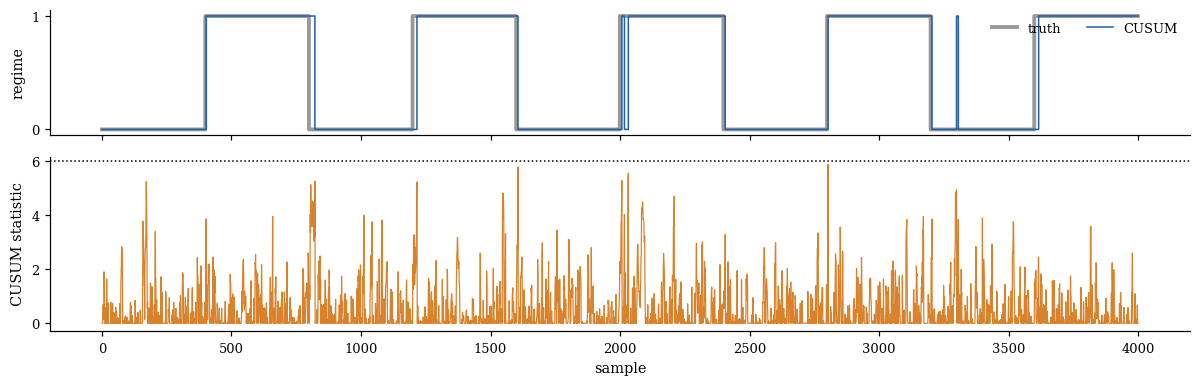

In [7]:
from lrdsr import CusumSegmenter

seg = np.repeat(np.arange(10) % 2, 400)
x = rng.uniform(-2, 2, seg.size)
yy = np.where(seg == 0, laws[0](x), laws[1](x)) + rng.normal(0, 2.0, seg.size)
rho = np.mean((2 * x) ** 2) / 2.0 ** 2
out = CusumSegmenter(laws[:2], sigma=2.0, threshold=6.0).run(x, yy)
switches = np.flatnonzero(np.diff(seg)) + 1
delays = [int(np.argmax(out.state.values[s:] == seg[s])) for s in switches]
print(f"rho = {rho:.3f}; theory delay 2h/rho = {2 * 6 / rho:.1f} samples; "
      f"measured mean delay {np.mean(delays):.1f}; accuracy {np.mean(out.state == seg):.3f}")

fig, ax = plt.subplots(2, 1, figsize=(11, 3.6), sharex=True,
                       gridspec_kw={"height_ratios": [1, 1.4]})
ax[0].step(np.arange(seg.size), seg, color="#999999", lw=2.5, label="truth")
ax[0].step(np.arange(seg.size), out.state, color=viz.PALETTE[0], lw=1.0, label="CUSUM")
ax[0].set(yticks=[0, 1], ylabel="regime"); ax[0].legend(ncol=2, loc="upper right")
ax[1].plot(out.cusum, color=viz.PALETTE[1], lw=0.8)
ax[1].axhline(6.0, color="k", ls=":", lw=1)
ax[1].set(xlabel="sample", ylabel="CUSUM statistic")
fig.tight_layout()